<a href="https://colab.research.google.com/github/SANDESHAHAHA/Data_Science/blob/main/Digit%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np


In [63]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [64]:
len(X_train)

60000

In [65]:
len(X_test)

10000

In [66]:
X_train=X_train/255
X_test=X_test/255

In [67]:
X_train.shape

(60000, 28, 28)

In [68]:
X_train[0].shape

(28, 28)

In [69]:
X_train[1]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [70]:
y_train[1]

np.uint8(0)

In [71]:
X_train_flattened=X_train.reshape(len(X_train),28*28)
X_train_flattened.shape

(60000, 784)

In [72]:
X_test_flattened=X_test.reshape(len(X_test),28*28)
X_test_flattened.shape

(10000, 784)

In [73]:
# X_train_flattened[0]

**Creating simple neural network**

so basically the input layer contains 784 neurons and output contains 10 neurons


In [74]:
model=keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation='sigmoid')
])
#olm
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train_flattened,y_train,epochs=10)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8140 - loss: 0.7120
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9145 - loss: 0.3160
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9214 - loss: 0.2826
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9242 - loss: 0.2747
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9252 - loss: 0.2679
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9281 - loss: 0.2577
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9280 - loss: 0.2591
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9276 - loss: 0.2587
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9310 - loss: 0.2529
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9314 - loss: 0.2490


In [75]:
model.evaluate(X_test_flattened,y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9167 - loss: 0.2964


[0.2628762722015381, 0.9269000291824341]

In [76]:
y_predicted=model.predict(X_test_flattened)
y_predicted[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([1.9723183e-01, 4.1854386e-03, 9.9973673e-01, 9.3330152e-02,
       9.6505512e-12, 8.5409886e-01, 8.7721676e-01, 1.0031521e-15,
       9.2977546e-02, 2.5068211e-12], dtype=float32)

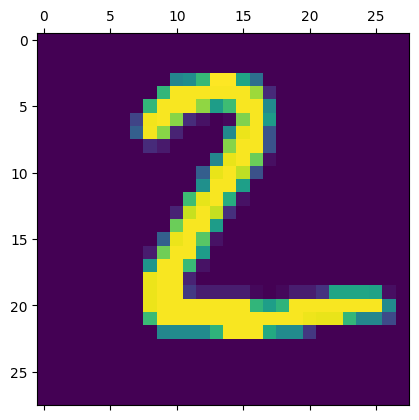

In [77]:
plt.matshow(X_test[1])

In [78]:
np.argmax(y_predicted[1])

np.int64(2)

**Drawing confusion matrix using tensorflow**

In [92]:
y_predicted_labels=[np.argmax(i) for i in y_predicted]
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [80]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [81]:
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 950,    0,    2,    2,    1,    7,   12,    4,    2,    0],
       [   0, 1109,    3,    2,    0,    1,    4,    2,   14,    0],
       [   3,    8,  932,   15,    8,    4,   12,   11,   37,    2],
       [   1,    0,   22,  918,    1,   19,    2,   10,   30,    7],
       [   1,    1,    6,    1,  915,    0,    9,    5,   10,   34],
       [   7,    2,    2,   38,   10,  769,   14,    9,   36,    5],
       [   8,    3,    9,    1,    7,   12,  912,    2,    4,    0],
       [   1,    6,   26,    2,    7,    1,    0,  956,    4,   25],
       [   3,    7,    6,   15,    9,   18,    7,   11,  891,    7],
       [   9,    7,    1,    7,   26,    6,    0,   23,   13,  917]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

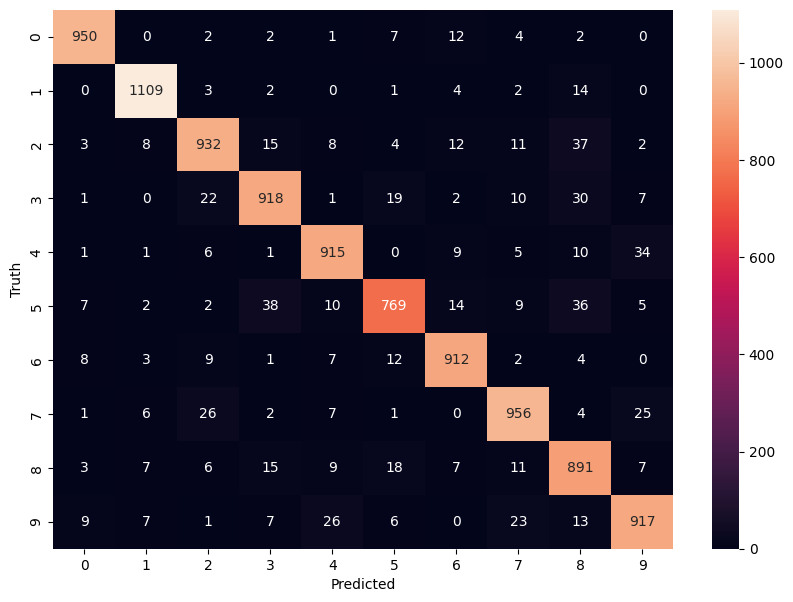

In [82]:
import seaborn as sns
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [84]:
model=keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])
#olm
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train_flattened,y_train,epochs=5)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8757 - loss: 0.4527
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9620 - loss: 0.1297
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9752 - loss: 0.0851
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9815 - loss: 0.0615
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9865 - loss: 0.0456


In [85]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9742 - loss: 0.0869


[0.07325300574302673, 0.9779999852180481]

In [86]:
y_predicted=model.predict(X_test_flattened)
y_predicted[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([3.59441299e-04, 9.81218874e-01, 9.99988079e-01, 7.18680084e-01,
       6.85766791e-11, 2.57921051e-02, 1.22325085e-02, 3.01089841e-07,
       1.36849642e-01, 1.14975570e-07], dtype=float32)

In [93]:
y_predicted_labels=[np.argmax(i) for i in y_predicted]
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [94]:
Cm=tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
Cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 972,    0,    2,    1,    0,    2,    2,    0,    1,    0],
       [   0, 1128,    1,    1,    0,    0,    2,    1,    2,    0],
       [   6,    5, 1009,    2,    1,    0,    3,    2,    4,    0],
       [   0,    1,    5,  989,    0,    4,    0,    6,    2,    3],
       [   2,    1,    6,    1,  946,    0,    8,    7,    3,    8],
       [   2,    1,    0,    9,    1,  869,    5,    1,    3,    1],
       [   4,    3,    1,    1,    2,    1,  946,    0,    0,    0],
       [   4,    3,    8,    0,    0,    0,    0, 1006,    2,    5],
       [   4,    2,    5,    4,    3,    3,    4,    3,  943,    3],
       [   3,    5,    0,    8,   10,    2,    1,    6,    2,  972]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

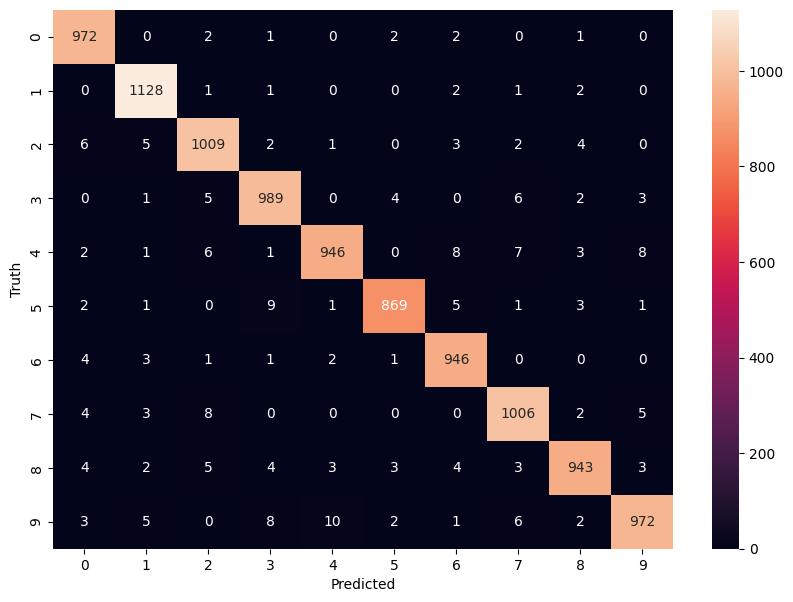

In [95]:
import seaborn as sns
plt.figure(figsize=(10,7))
sns.heatmap(Cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [96]:
#without doing the flatten array you can you inbuilt function oftensorflw
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(10,activation='sigmoid')
])
#olm
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train,y_train,epochs=10)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8145 - loss: 0.7150
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9141 - loss: 0.3089
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9220 - loss: 0.2804
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9232 - loss: 0.2769
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9255 - loss: 0.2668
Epoch 6/10
1271/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9287 - loss: 0.2592

KeyboardInterrupt: 